In [8]:
from tqdm import tqdm
import matplotlib.pyplot as plt
from pathlib import Path

from util_dicom import *

url = "https://orthanc.unboxed-2026.ovh"
username='unboxed'
password='unboxed2026'

client = Client(url, username, password)

In [ ]:
studies = client.get_studies()
print(studies)

for study in studies:
    client.download_study(study)


In [ ]:
patients = client.get_patients()

studies = client.get_studies(patient=patients[0])

series = client.get_series()

In [9]:
from util_dicom.py import *

path = "/home/jovyan/work/dataset"
patientID = "17A76C2A"
AccessionNumber = "26721665 TC TRAX"

study_dir = Path(path) / patientID / AccessionNumber
series_list = [str(item) for item in study_dir.iterdir() if item.is_dir()]

#print(series_list)
print(get_series(study_id))

ModuleNotFoundError: No module named 'util_dicom.py'; 'util_dicom' is not a package

In [10]:
import dcm_seg_nodules
from dcm_seg_nodules import extract_seg
from util_dicom import *
from lungmask import LMInferer
import numpy as np
import os

os.environ['TORCH_HOME'] = '/home/jovyan/work'

input_serie = "/home/jovyan/work/dataset/0301B7D6/11092835 TC TRAX TC ABDOMEN TC PELVIS/CT CEV torax/"
output_folder = "/home/jovyan/work/output"

img_base = get_array(input_serie)
inferer = LMInferer(force_cpu=True)
lung_mask = inferer.apply(img_base)

masked_img = img_base[20] * lung_mask[20]
show_image(masked_img)

  0%|          | 0/4.6 [00:02<?, ?it/s]

KeyboardInterrupt



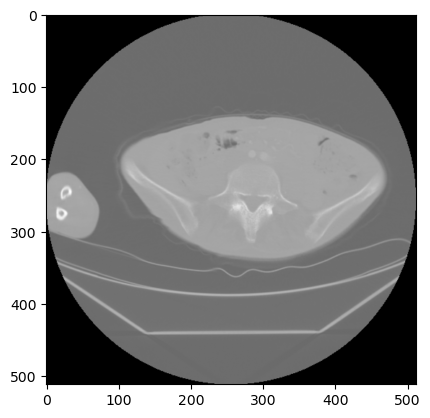

In [11]:
import dcm_seg_nodules
from dcm_seg_nodules import extract_seg
from util_dicom import *
input_serie = "/home/jovyan/work/dataset/0301B7D6/11092835 TC TRAX TC ABDOMEN TC PELVIS/CT CEV torax/"
output_folder = "/home/jovyan/work/output"
img_base = get_array(input_serie)
show_image(img_base[20])

In [5]:
from util_dicom.py import *

def get_volume(array_lesion, resolution: float) -> float:
    return array_lesion.sum() * resolution

input_serie = "/home/jovyan/work/dataset/0301B7D6/11092835 TC TRAX TC ABDOMEN TC PELVIS/CT CEV torax/"
output_folder = "/home/jovyan/work/output"

img_base, resolution = get_array(input_serie)
show_image(img_base[0][8])

lesions = get_lesions(input_serie)
show_image(lesions[0][8])


volume = get_volume(lesions, resolution)

print(volume,resolution)


ModuleNotFoundError: No module named 'util_dicom.py'; 'util_dicom' is not a package